In [2]:
##
# Measure ICA component inf-norms (max component)
# compare it with the elementwise KL div
#

import pandas as pd
import numpy as np
import scipy as sp
import sklearn
import importlib
import databox as db
import joblib
from hashlib import md5
# import sample_group_stats as sgst
from sklearn.mixture import BayesianGaussianMixture
from sklearn.decomposition import FastICA
import extools as ex
import scipy.stats as st
import scipy.special as sp

OK -- read the ontology db (19571, 4)
Restored 303734 tags and 191240 tokens. Run update_corpus_tagdata() to update.
-- loaded the skipgram model tank/fasttext_8.model --


In [3]:
# Read in the syntactic context encodings (CE)

ce_df = pd.read_parquet("data/q_sep/context_encoding_df.pq").\
            reset_index().set_index(['category','token_id'])

In [4]:
# Read in term feature data frame (TF)

tf_df = pd.read_parquet("data/q_sep/token_features.pq")

In [5]:
tf_df.sample(4)

token_form  \
category   token                     widx                
topic      Bum-e9d6_221_bumblebees-3 18     bumblebees   
           For-fc8f_24_aphids-34     31         aphids   
location   Afr-354e_4_rainforests-13 5     rainforests   
taxongroup Chib5c1_9_chimpanzee-9    5      chimpanzee   

                                                                                 concept_uri  \
category   token                     widx                                                      
topic      Bum-e9d6_221_bumblebees-3 18                                      Bumblebee#genus   
           For-fc8f_24_aphids-34     31                                     Aphididae#family   
location   Afr-354e_4_rainforests-13 5     Tropical_and_subtropical_moist_broadleaf_fores...   
taxongroup Chib5c1_9_chimpanzee-9    5                                      Chimpanzee#genus   

                                                      arcpath     lemma upos  \
category   token                     widx                                      
topic      Bum-e9d6_221_bumblebees-3 18      nsubj<conj>amod>     other  ADJ   
           For-fc8f_24_aphids-34     31            nmod<amod>  frequent  ADJ   
location   Afr-354e_4_rainforests-13 5     obl<acl:relcl<det>       the  DET   
taxongroup Chib5c1_9_chimpanzee-9    5                   cop>        be  AUX   

                                                   sample_grp  
category   token                     widx                      
topic      Bum-e9d6_221_bumblebees-3 18    Hymenoptera__order  
           For-fc8f_24_aphids-34     31         Insect__class  
location   Afr-354e_4_rainforests-13 5          Bovid__family  
taxongroup Chib5c1_9_chimpanzee-9    5         Primate__order

In [6]:
ica8 = joblib.load("data/q_sep/CE-ICA_transformer_w_8-dim.pkl")

In [7]:
#fdata = tf_df.iloc[0]
#np.abs(ex.compute_feat_vec(fdata.arcpath,fdata.lemma,ica8)).max()

In [8]:
# Compute a pivot table for feature counts (frequencies)
# in each category

f_df = tf_df.reset_index().groupby(['category','arcpath']).lemma.value_counts()
f_df = pd.DataFrame(f_df).reset_index().set_index(['arcpath','lemma'])

feat_freq_df = f_df.pivot(columns='category').fillna(0).astype(int)
feat_freq_df.sample(5)

count                          
category                        adaptation location taxongroup topic
arcpath         lemma                                               
conj<obj<advcl> keep                     0        0          0     1
obl<conj>nmod>  area                     0        4          0     0
nmod>           tail                     0        0          2     3
obj<acl<        Australovenator          0        0          0     1
obl<amod<ccomp> have                     0        0          0     1

In [9]:
# Compute category-wise feature distributions
#
# for computing element-wise relative entropy
#
# feat P = feature probability distributions for each 4 category columns
# feat Q = row-wise reference distribution, averaged, non-weighted

feat_p = np.array(feat_freq_df)
feat_p = feat_p / feat_p.sum(axis=0)
feat_p.shape 

feat_q = feat_p.sum(axis=1)/feat_p.shape[1]

feat_p.shape, feat_q.shape

((224304, 4), (224304,))

In [10]:
# Compute the element-wise relative entropy

feat_el_kldiv = np.array([sp.rel_entr(feat_p[:,i],feat_q) for i in range(feat_p.shape[1])]).T
feat_el_kldiv_df = pd.DataFrame(feat_el_kldiv,
                                index=feat_freq_df.index,
                                columns=feat_freq_df.columns.droplevel(0))
feat_el_kldiv_df['feat_Q']=feat_q
feat_kld = feat_el_kldiv_df.sort_values('feat_Q',ascending=False).head(100).round(4)


In [11]:
# Add the i-norm (inf norm or max comp value) of the feature as a comparison

feat_inorms = [np.abs(ex.compute_feat_vec(arcpath,lemma,ica8)).max().round(3) 
   for (arcpath,lemma) in feat_kld.index]

feat_kld['inorm']=feat_inorms
feat_kld.head(10)

,category,adaptation,location,taxongroup,topic,feat_Q,inorm
arcpath,lemma,,,,,,
det>,the,-0.0048,0.0046,0.0007,0.0029,0.0135,0.848
case>,of,-0.0019,-0.0016,0.0035,0.0012,0.0085,0.691
conj>cc>,and,-0.0008,0.0026,-0.0016,0.0006,0.0063,0.561
cc>,and,-0.0011,0.0007,-0.0007,0.0015,0.0053,0.671
case>,in,-0.0018,0.0132,-0.0019,-0.0018,0.0050,0.657
cop>,be,0.0110,-0.0014,-0.0006,-0.0017,0.0046,0.287
nmod<det>,the,-0.0008,-0.0002,0.0005,0.0007,0.0042,0.432
conj<conj>cc>,and,-0.0015,0.0018,-0.0009,0.0029,0.0041,0.357
nsubj<cop>,be,0.0002,-0.0013,-0.0003,0.0025,0.0035,0.318


In [12]:
cat_d = feat_freq_df.sum(axis=0)
cat_Q = cat_d / sum(cat_d)
cats = pd.DataFrame({'N':cat_d,'Q':cat_Q})
cats.index = cats.index.droplevel(0)
cats

,N,Q
category,,
adaptation,39852,0.064502
location,26977,0.043664
taxongroup,112987,0.182875
topic,438021,0.708959


In [13]:
print(cats.T.to_latex())

\begin{tabular}{lrrrr}
\toprule
category & adaptation & location & taxongroup & topic \\
\midrule
N & 39852.000000 & 26977.000000 & 112987.000000 & 438021.000000 \\
Q & 0.064502 & 0.043664 & 0.182875 & 0.708959 \\
\bottomrule
\end{tabular}



In [89]:
book_feat_kld=feat_kld[cats.index].copy()
book_feat_kld['N']=feat_freq_df.sum(axis=1)
book_feat_kld = book_feat_kld.sort_values('N',ascending=False).head(10)

book_df=book_feat_kld.copy()
book_df['D']=book_df[cats.index].sum(axis=1)
book_df=book_df[['D']+list(cats.index)+['N']]
book_df = book_df.round(5).astype(str)
print(book_df.reset_index().to_latex(index=False))

\begin{tabular}{llllllll}
\toprule
arcpath & lemma & D & adaptation & location & taxongroup & topic & N \\
\midrule
det> & the & 0.0034 & -0.0048 & 0.0046 & 0.0007 & 0.0029 & 9397 \\
case> & of & 0.0012 & -0.0019 & -0.0016 & 0.0035 & 0.0012 & 5954 \\
conj>cc> & and & 0.0008 & -0.0008 & 0.0026 & -0.0016 & 0.0006 & 3945 \\
cc> & and & 0.0004 & -0.0011 & 0.0007 & -0.0007 & 0.0015 & 3733 \\
conj<conj>cc> & and & 0.0023 & -0.0015 & 0.0018 & -0.0009 & 0.0029 & 3350 \\
nsubj<cop> & be & 0.0011 & 0.0002 & -0.0013 & -0.0003 & 0.0025 & 2978 \\
nmod<det> & the & 0.0002 & -0.0008 & -0.0002 & 0.0005 & 0.0007 & 2865 \\
det> & a & 0.0012 & 0.0018 & -0.0011 & 0.0002 & 0.0003 & 2030 \\
cop> & be & 0.0073 & 0.011 & -0.0014 & -0.0006 & -0.0017 & 1790 \\
nsubj:pass<aux:pass> & be & 0.0004 & -0.0005 & -0.0006 & 0.0 & 0.0015 & 1779 \\
\bottomrule
\end{tabular}



In [90]:
book_df

,category,D,adaptation,location,taxongroup,topic,N
arcpath,lemma,,,,,,
det>,the,0.0034,-0.0048,0.0046,0.0007,0.0029,9397
case>,of,0.0012,-0.0019,-0.0016,0.0035,0.0012,5954
conj>cc>,and,0.0008,-0.0008,0.0026,-0.0016,0.0006,3945
cc>,and,0.0004,-0.0011,0.0007,-0.0007,0.0015,3733
conj<conj>cc>,and,0.0023,-0.0015,0.0018,-0.0009,0.0029,3350
nsubj<cop>,be,0.0011,0.0002,-0.0013,-0.0003,0.0025,2978
nmod<det>,the,0.0002,-0.0008,-0.0002,0.0005,0.0007,2865
det>,a,0.0012,0.0018,-0.0011,0.0002,0.0003,2030
cop>,be,0.0073,0.011,-0.0014,-0.0006,-0.0017,1790


In [85]:
lengthwise_df = feat_kld[feat_kld.columns[0:4]].\
    merge(pd.DataFrame(feat_freq_df.sum(axis=1),columns=['N']),
          left_index=True,right_index=True).\
    sort_values('N',ascending=False)
lengthwise_df['max_D']=lengthwise_df[list(cats.index)].max(axis=1)
lengthwise_df = lengthwise_df.sort_values('max_D',ascending=False).head(10)
l_df = lengthwise_df[lengthwise_df.columns[:-1]]
l_df



adaptation  location  taxongroup   topic     N
arcpath       lemma                                                
amod<         bear       0.0000    0.0157      0.0000  0.0000   305
case>         in        -0.0018    0.0132     -0.0019 -0.0018  1692
cop>          be         0.0110   -0.0014     -0.0006 -0.0017  1790
compound<det> the       -0.0012    0.0056     -0.0010 -0.0007  1570
det>          the       -0.0048    0.0046      0.0007  0.0029  9397
nmod>case>    of         0.0042    0.0003     -0.0011 -0.0012  1198
amod>         human      0.0041   -0.0001      0.0000 -0.0001   131
              other      0.0002   -0.0005      0.0038 -0.0007  1230
compound<     hare       0.0000    0.0035     -0.0001 -0.0000    76
case>         of        -0.0019   -0.0016      0.0035  0.0012  5954

In [86]:
ll_df = l_df.copy()
ll_df['D sum']=l_df[cats.index].sum(axis=1).round(5)
ll_df=ll_df[['D sum']+list(l_df.columns)]
print(ll_df.reset_index().astype(str).to_latex(index=False)) # for the book

\begin{tabular}{llllllll}
\toprule
arcpath & lemma & D sum & adaptation & location & taxongroup & topic & N \\
\midrule
amod< & bear & 0.0157 & 0.0 & 0.0157 & 0.0 & 0.0 & 305 \\
case> & in & 0.0077 & -0.0018 & 0.0132 & -0.0019 & -0.0018 & 1692 \\
cop> & be & 0.0073 & 0.011 & -0.0014 & -0.0006 & -0.0017 & 1790 \\
compound<det> & the & 0.0027 & -0.0012 & 0.0056 & -0.001 & -0.0007 & 1570 \\
det> & the & 0.0034 & -0.0048 & 0.0046 & 0.0007 & 0.0029 & 9397 \\
nmod>case> & of & 0.0022 & 0.0042 & 0.0003 & -0.0011 & -0.0012 & 1198 \\
amod> & human & 0.0039 & 0.0041 & -0.0001 & 0.0 & -0.0001 & 131 \\
amod> & other & 0.0028 & 0.0002 & -0.0005 & 0.0038 & -0.0007 & 1230 \\
compound< & hare & 0.0034 & 0.0 & 0.0035 & -0.0001 & -0.0 & 76 \\
case> & of & 0.0012 & -0.0019 & -0.0016 & 0.0035 & 0.0012 & 5954 \\
\bottomrule
\end{tabular}



In [87]:
# widthwise df  # EXPERIMENTAL ONLY
wdf = feat_freq_df.loc[lengthwise_df.index]
w_df = (wdf.T / wdf.sum(axis=1)).round(2).T
w_df.columns = w_df.columns.droplevel(0)
#print(w_df)

ww_df = pd.DataFrame([sp.rel_entr(w_df.loc[i],cats.Q) for i in w_df.index], index=w_df.index)
w_df = ww_df.T.copy().round(4)
w_df['N']=cats.N
w_df['Q']=cats.Q.round(4)
w_df = w_df.T
w_df

category             adaptation    location   taxongroup        topic
arcpath       lemma                                                  
amod<         bear       0.0000      3.1312       0.0000       0.0000
case>         in        -0.0043      0.3298      -0.0444      -0.1001
cop>          be         0.3624     -0.0147       0.0782      -0.1932
compound<det> the       -0.0230      0.1213      -0.0374      -0.0089
det>          the       -0.0230      0.0068      -0.0124       0.0422
nmod>case>    of         0.2699      0.0484       0.0073      -0.1680
amod>         human      2.4085     -0.0147       0.0000      -0.1745
              other      0.0172      0.0000       0.4052      -0.1932
compound<     hare       0.0000      2.7636      -0.0672      -0.0949
case>         of        -0.0191     -0.0113       0.0407       0.0010
N                    39852.0000  26977.0000  112987.0000  438021.0000
Q                        0.0645      0.0437       0.1829       0.7090

In [18]:
# print(w_df.reset_index().to_latex(index=False)) # for the book

Text(0.5, 0.98, 'Elementwise relative entropy Dx (KL divergence) of normalized feature probability: \nfeature probability distribution Pc within category against averaged distribution Q in all categories')

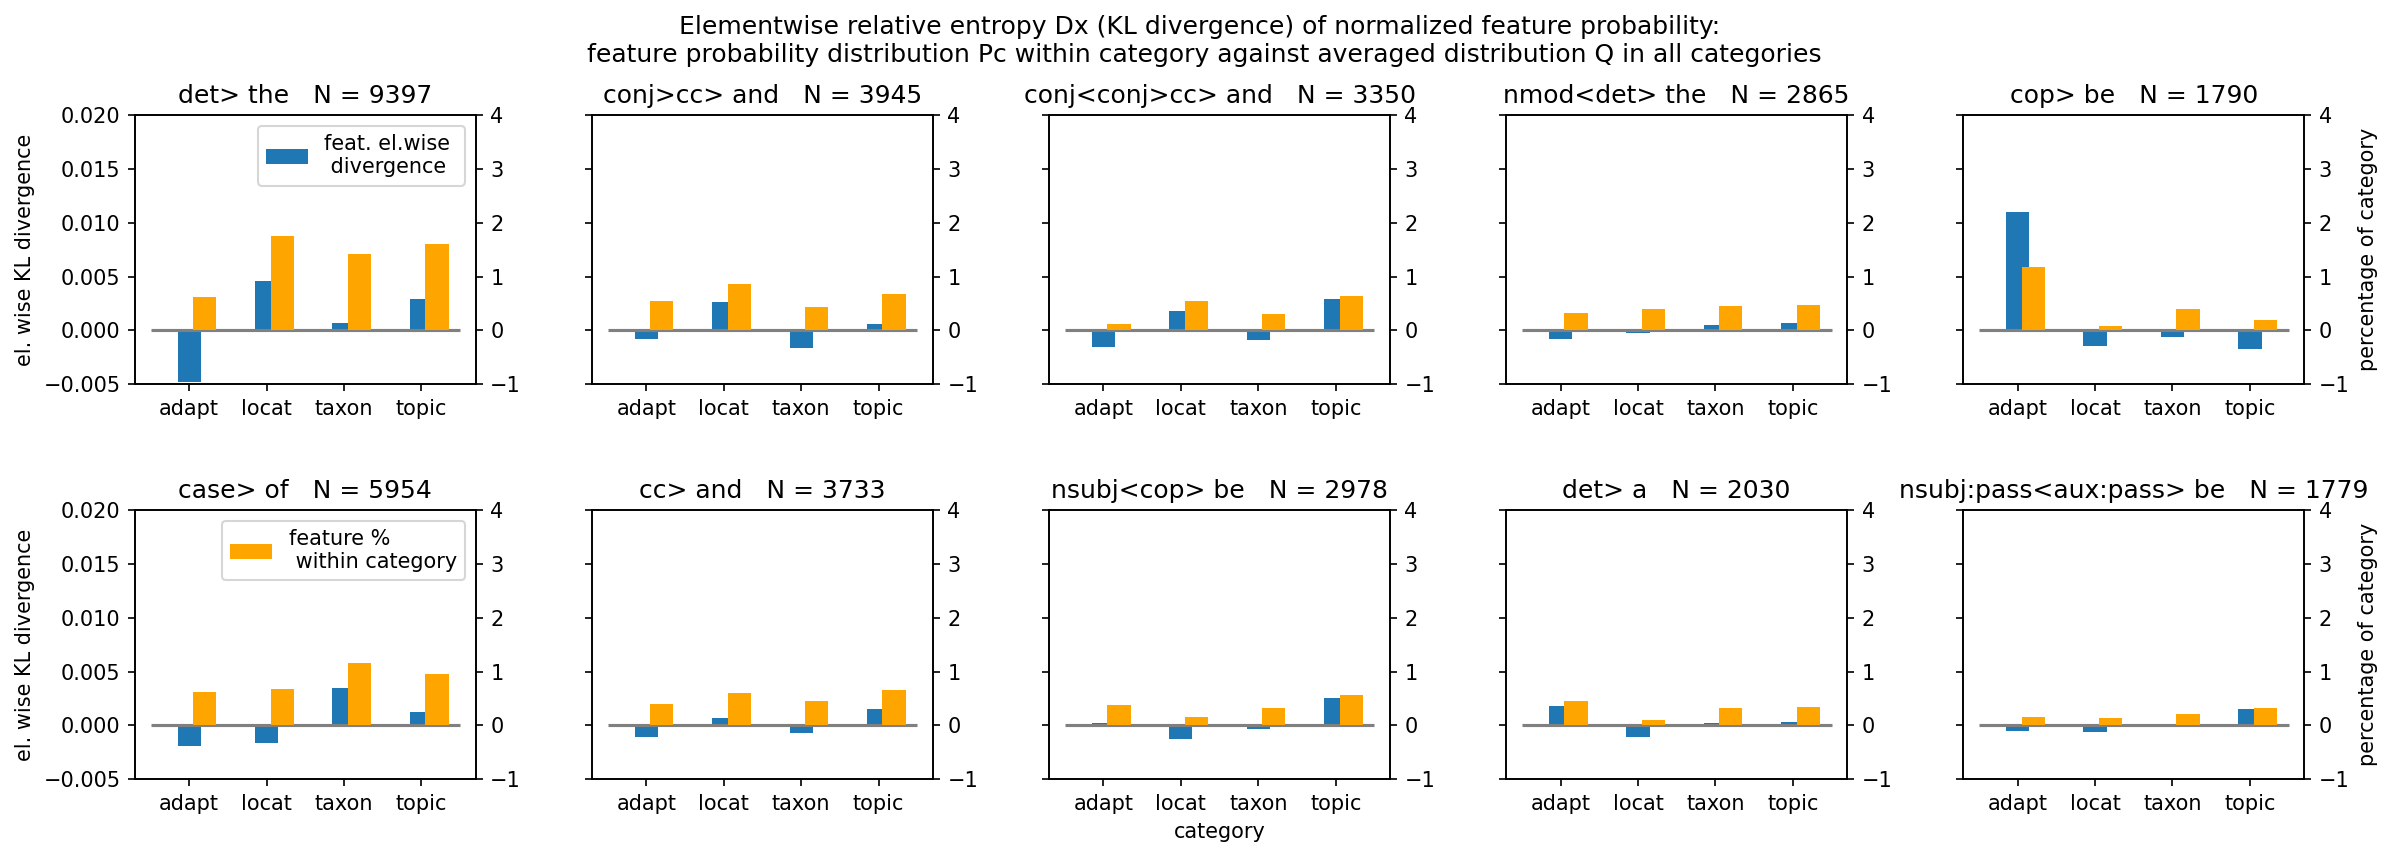

In [93]:
from matplotlib import pyplot as plt

n_top = 10
cols = feat_kld.columns[0:4]

fig, axs = plt.subplots(2,5,figsize=(16,6),dpi=150,sharey=True)
fig.tight_layout(h_pad=4,w_pad=4,pad=4,rect=(0,0,1,.97))


d=[]
for i in range(n_top):
    feat=book_feat_kld.index[i]
    ax = axs[i%2][i//2]
    ax.bar(book_feat_kld.columns[0:4].str[0:5],height=list(book_feat_kld.iloc[i][0:4]),width=.3)
    nD = feat_freq_df.loc[feat]
    nD/=cats.N
    
    ax.set_ylim([-.005, .020])
    ax2=ax.twinx()
    ax2.set_ylim([-1, 4.0])
    ax2.bar(np.arange(0.2,4,1),height=list(100*nD),width=.3,color='orange')
    

    
    ax.set_title(' '.join(feat)+'   N = %d'%(book_feat_kld.iloc[i].N))
    if (i==0):
        ax.legend(['feat. el.wise \n divergence'])
    if (i==1):
        ax2.legend(['feature % \n within category'])

    if (i<=1):
        ax.set_ylabel('el. wise KL divergence')
    if (i==5):
        ax.set_xlabel('category')
    if (i>=8):
        ax2.set_ylabel('percentage of category')
        
    ax.hlines(0,-.5,3.5,color='gray')

fig.suptitle('Top 10 feature frequencies and el. w. KL div')
fig.suptitle('Elementwise relative entropy Dx (KL divergence) of normalized feature probability: \n'+
             'feature probability distribution Pc within category against averaged distribution Q in all categories')


In [29]:
#feat_freq_df.loc[book_feat_kld.index]
cats.N

category
adaptation     39852
location       26977
taxongroup    112987
topic         438021
Name: N, dtype: int64

Text(0.5, 0.98, 'Elementwise relative entropy Dx (KL divergence) of normalized feature probability: \nfeature probability distribution Pc within category against averaged distribution Q in all categories')

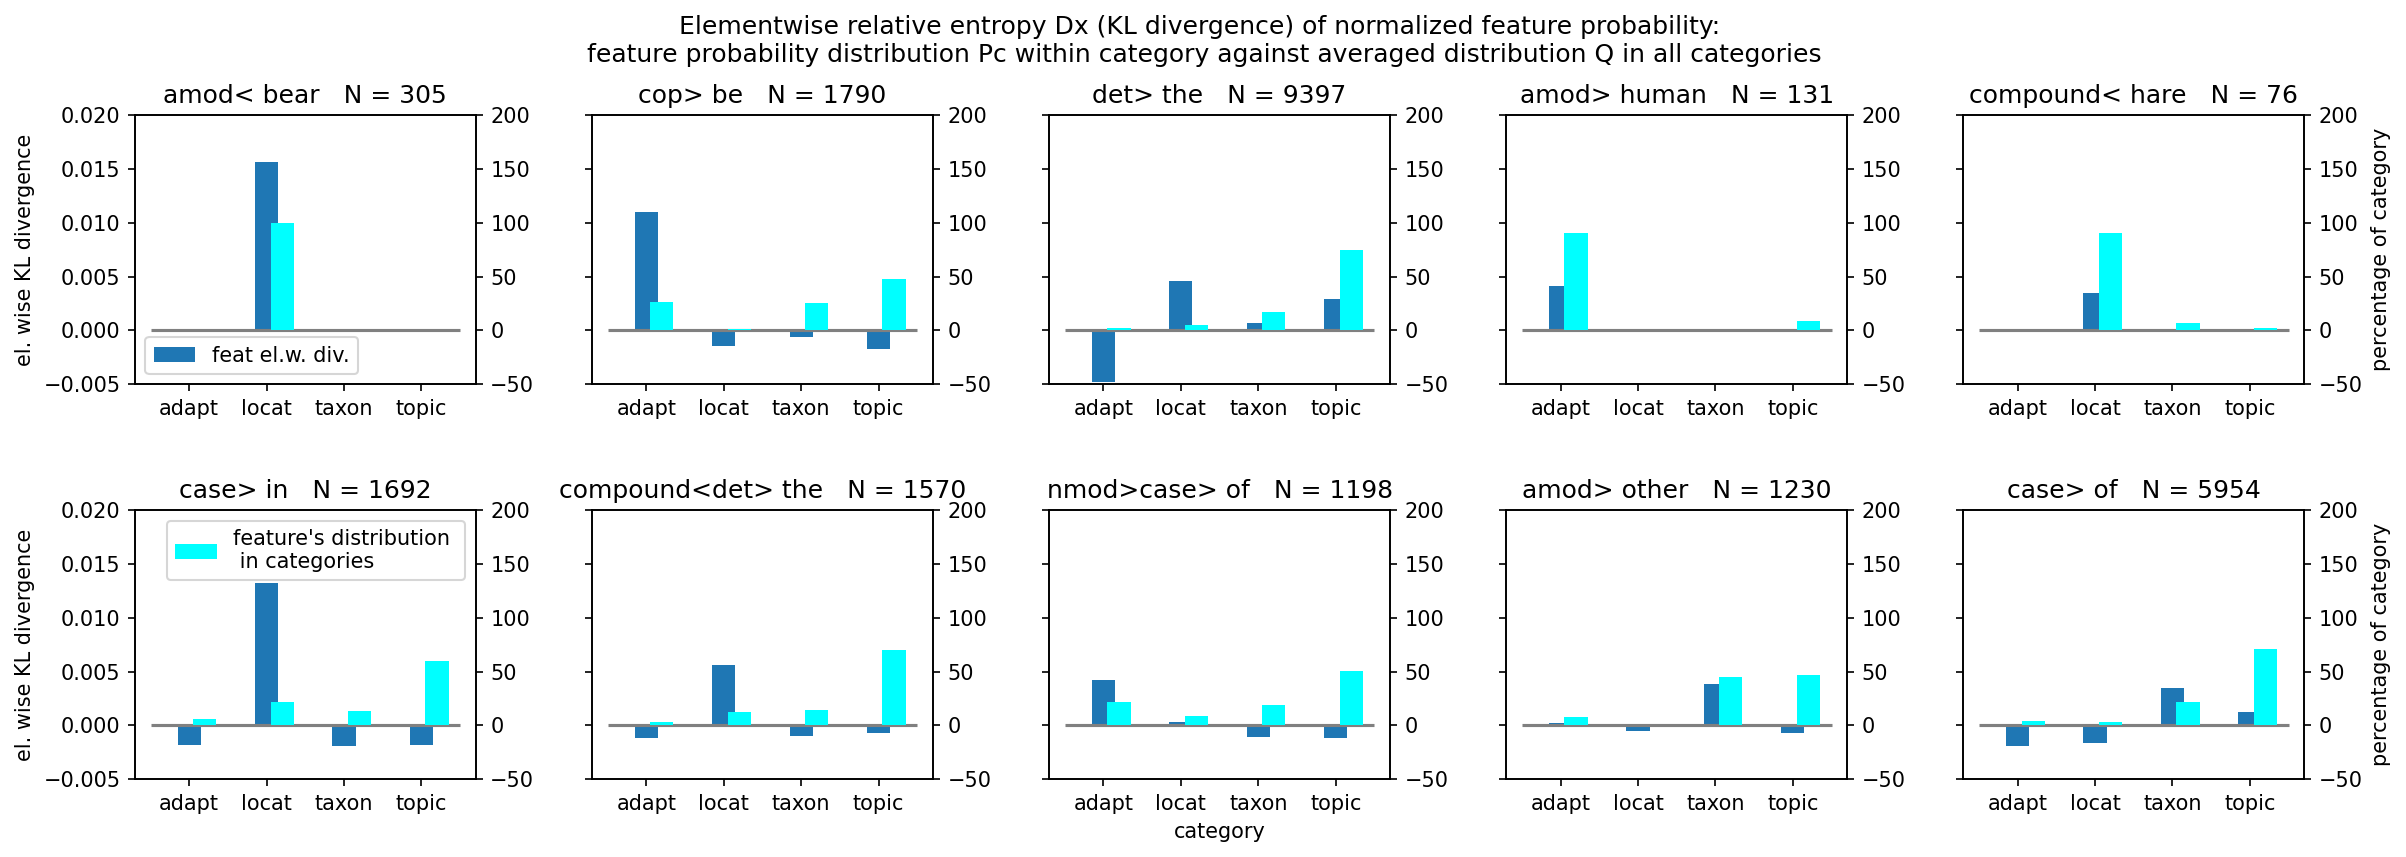

In [92]:
n_top = 10
cols = feat_kld.columns[0:4]

fig, axs = plt.subplots(2,5,figsize=(16,6),dpi=150,sharey=True)
fig.tight_layout(h_pad=4,w_pad=4,pad=4,rect=(0,0,1,.97))


d=[]
for i in range(n_top):
    feat=l_df.index[i]
    ax = axs[i%2][i//2]
    ax.bar(l_df.columns[0:4].str[0:5],height=list(l_df.iloc[i][0:4]),width=.3)
    nD = feat_freq_df.loc[feat]
    nD/=nD.sum()
    
    ax.set_ylim([-.005, .020])
    ax2=ax.twinx()
    ax2.set_ylim([-50, 200])
    ax2.bar(np.arange(0.2,4,1),height=list(100*nD),width=.3,color='cyan')


    ax.set_title(' '.join(feat)+'   N = %d'%(l_df.iloc[i].N))
    if (i==0):
        ax.legend(['feat el.w. div.'])
    if (i==1):
        ax2.legend(['feature\'s distribution \n in categories'])

    if (i<2):
        ax.set_ylabel('el. wise KL divergence')
    if (i==5):
        ax.set_xlabel('category')
    if (i>7):
        ax2.set_ylabel('percentage of category')

    ax.hlines(0,-.5,3.5,color='gray')
fig.suptitle('Elementwise relative entropy Dx (KL divergence) of normalized feature probability: \n'+
     'feature probability distribution Pc within category against averaged distribution Q in all categories')


Text(0.5, 0.98, 'Comparison between feature and category dimensions in element-wise KL div')

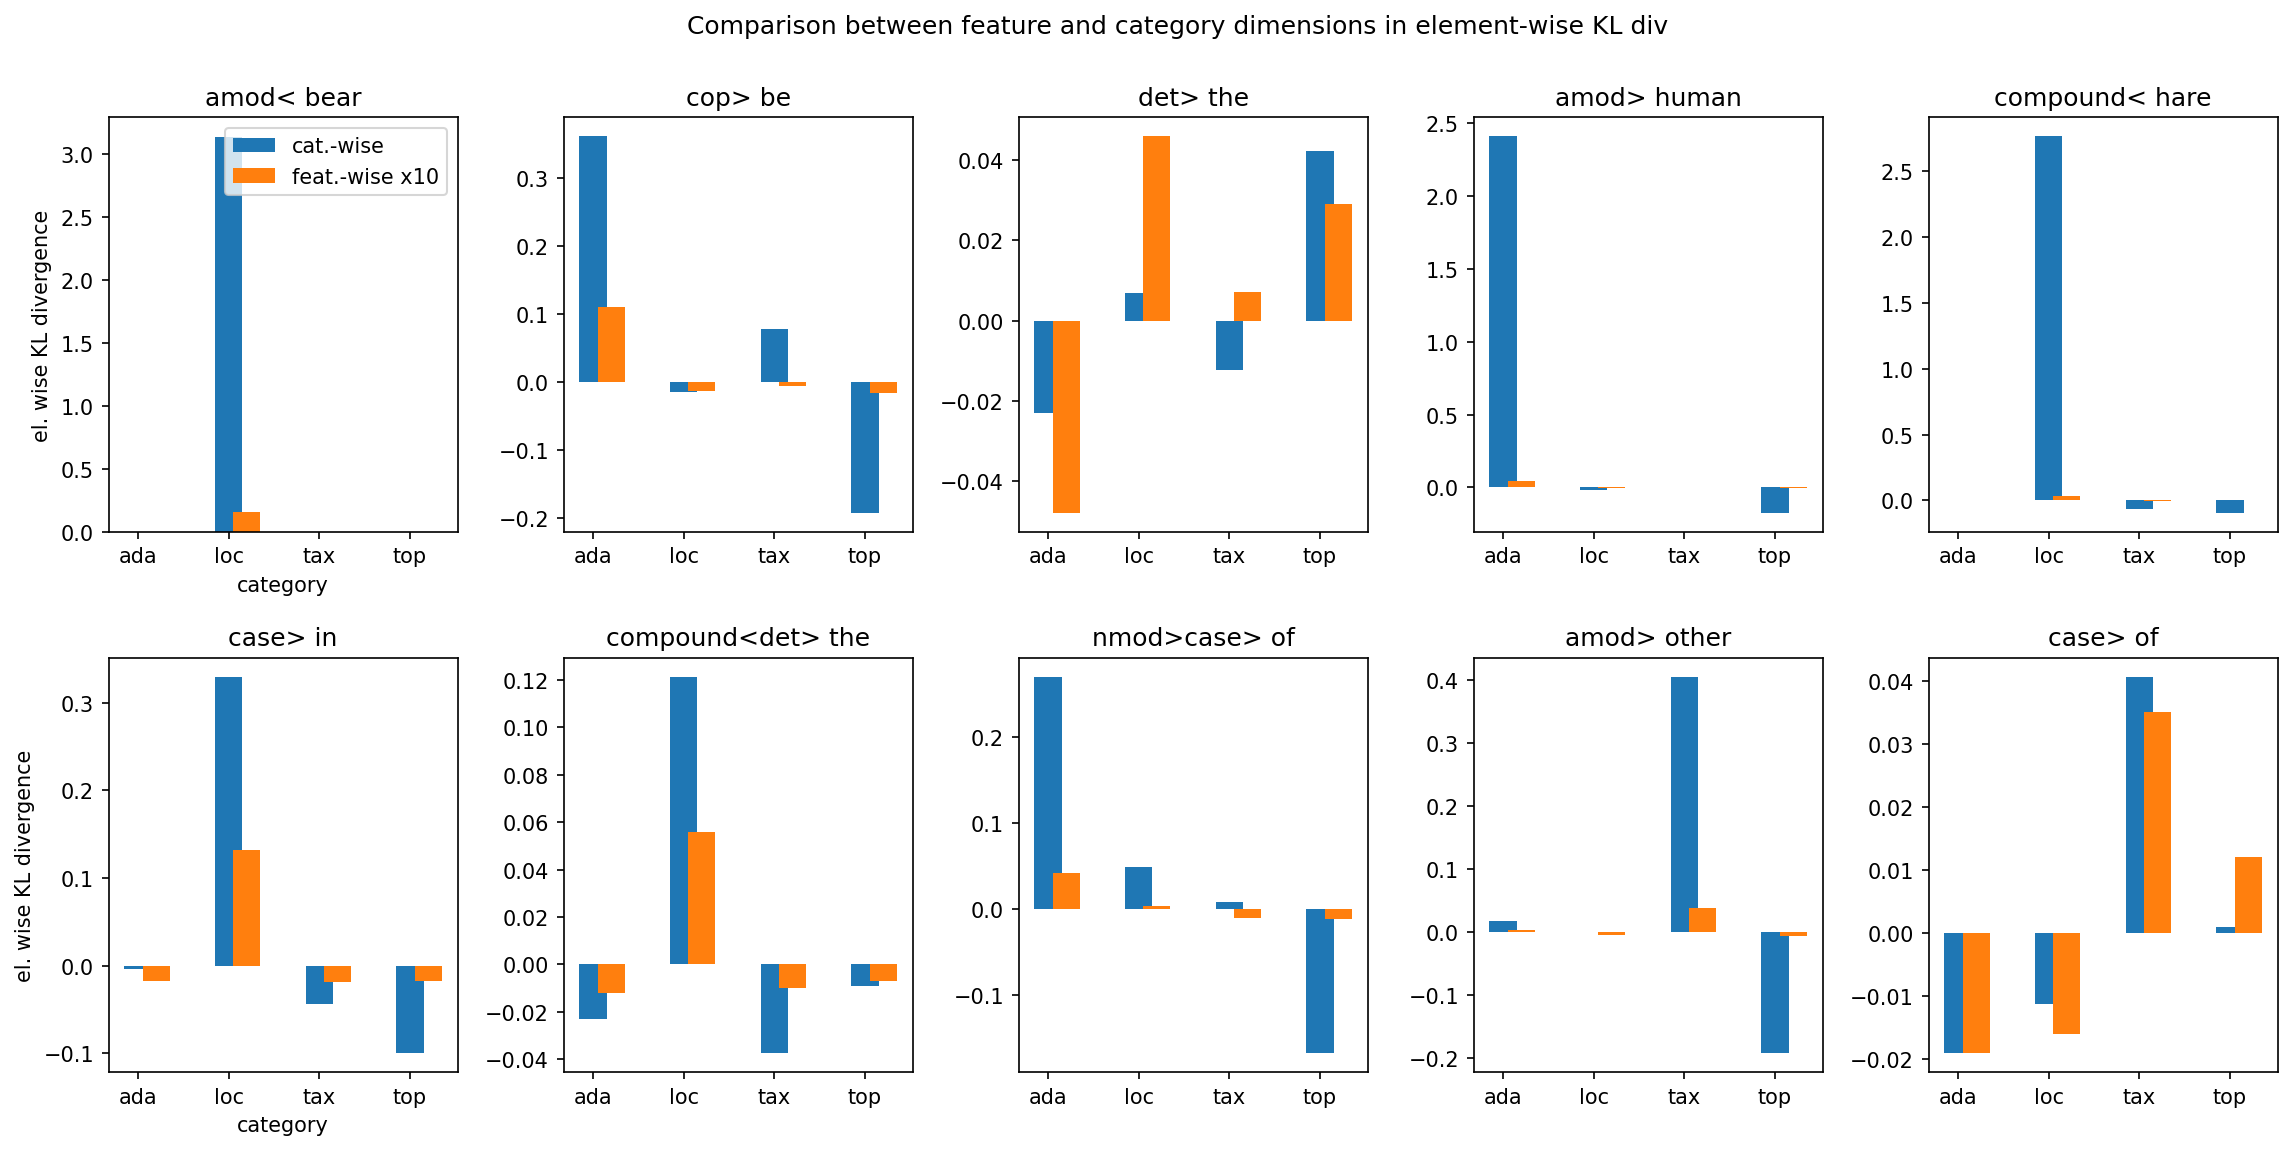

In [41]:
n_top = 10
cols = feat_kld.columns[0:4]

fig, axs = plt.subplots(2,5,figsize=(16,8),dpi=150)
fig.tight_layout(h_pad=4,w_pad=2,pad=4,rect=(0,0,1,.97))


d=[]
for i in range(n_top):
    feat=w_df.index[i]
    ax = axs[i%2][i//2]
    ax.bar(list(cols.str[0:3]),height=w_df.iloc[i],width=.3)
    ax.bar(np.arange(0.2,4,1),height=list(10*l_df.iloc[i][0:4]),width=.3)
    ax.set_title(' '.join(feat))
    if (i==0):
        ax.legend(['cat.-wise','feat.-wise x10'])

    if (i<2):
        ax.set_ylabel('el. wise KL divergence')
        ax.set_xlabel('category')

fig.suptitle('Comparison between feature and category dimensions in element-wise KL div')


In [ ]:
# For the book - most divergent features

df = feat_kld[feat_kld.columns[0:4]].melt(ignore_index=False).reset_index()\
.merge(f_df.reset_index(),on=['category','arcpath','lemma'])\
.rename(columns={'value':'Dx'}).sort_values(by=['category','Dx'],ascending=[True,False]).set_index(['arcpath','lemma'])
df['inorm']=feat_kld['inorm'].loc[df.index]
df = df.reset_index().set_index(['category','arcpath','lemma'])
book_ax_dx = df.groupby('category').head(15)
book_ax_dx

In [ ]:
print(book_ax_dx.reset_index().to_latex(index=False))

In [ ]:
from matplotlib import pyplot as plt

In [ ]:
list(feat_kld.inorm)[0]

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(12,5),dpi=150)
fig.tight_layout(pad=3,rect=(0,0,1,.85))
ax1,ax2=axs

markers = '*ox.+'
cols = feat_kld.columns[0:4]
for c in cols:
    ax1.plot(list(feat_kld.inorm),list(feat_kld[c]),markers[0])
    markers=markers[1:]

ax1.legend(list(cols))

ax1.set_xlabel('IC axis projection norm')

ax1.set_title('Element-wise relative entropy: \n'+
              'Category-specific vs averaged frequencies \n'+
              ' compared to ICA projection max component value.')
ax1.set_ylabel('Element-wise KL Divergence \n (category frequency || combined frequency)')



res = st.linregress(feat_kld.inorm,feat_kld.feat_Q)
x = np.arange(0.2,1,0.1)




ax2.plot(list(feat_kld.inorm),list(feat_kld.feat_Q),'^')
ax2.plot(x, res.intercept + res.slope*x, 'r')

ax2.legend(['Q','fitted line'])
ttext="R2 = %.6f, intercept %.6f, slope %.6f"%(res.rvalue**2,res.intercept,res.slope)
ax2.set_title('Feature frequency averaged over 4 categories (Q) \n'+
              ' compared to ICA projection max component value.\n'+ttext)
ax2.set_xlabel('IC axis projection norm')
ax2.set_ylabel('Feature frequency')

fig.suptitle("Exploring category specific features:\n"+
             "Feature frequency compared to the feature vector ICA axis projection norm.")

ax1.hlines(0,0.1,1)

plt.show()

In [ ]:
fig, axs = plt.subplots(2,2,figsize=(12,8),sharex=True,dpi=150)
fig.tight_layout(pad=4,rect=(0,0,1,.90))

cols = feat_kld.columns[0:4]

n_top = 25
for i in range(len(cols)):
    ax = axs[i//2][i%2]
    col = cols[i]

    d = feat_kld[['inorm',col,'feat_Q']].sort_values(by=col,ascending=False).head(n_top)

    X=d.inorm
    y=d[col]
    
    if(i%2==0):
        ax.set_ylabel('Element-wise KL divergence \n of feature category frequency \n vs. combined frequency distribution')

    if(i//2):
        ax.set_xlabel('IC axis projection norm')
 
    
    ax.plot(list(X),list(y),'o')
    
    # Linear regression fitting
    
    res = st.linregress(X,y)
    x = np.arange(X.min()*.9,X.max()*1.1,X.max()/10)
    ax.plot(x, res.intercept + res.slope*x, 'r')
    
    for n in range(3):
        ax.text(X[n]*.95,y[n]*(.98-0.03*n),'\n'.join(d.index[n]),rotation=0,ha='left',va='top')

    ax.legend([col,'fitted line'])
    ttxt = ("R2 = %.6f, intercept %.6f, slope %.6f"%(res.rvalue**2,res.intercept,res.slope))
    
    ax.set_title(col+" category features\n"+ttxt)
    
fig.suptitle('Element-wise relative entropy of categories feature frequencies \n'+
             ' compared to feature vectors ICA component max component value (inf-norm). \n '+
            'Shown: %d features of highest divergence per category' % n_top)    

    

In [ ]:
n_top = 10
cols = feat_kld.columns[0:4]

fig, axs = plt.subplots(2,2,figsize=(12,8),sharex=True,dpi=150)
fig.tight_layout(h_pad=6,w_pad=20,pad=6,rect=(0,0,1,.95))


d=[]
for i in range(len(cols)):
    col=cols[i]
    ax = axs[i//2][i%2]

    df = feat_kld[['inorm',col]].rename(columns={col:'Dx'}).assign(category=col).\
            sort_values(by='Dx',ascending=False).head(n_top).\
            reset_index().sort_values(by='inorm',ascending=True)
    
    ax.barh(df.arcpath+" "+df.lemma,df.inorm,height=.2)
    ax.barh(list(np.arange(.2,n_top,1)),df.Dx*100,height=.2)
    ax.legend(['ICA axis norm','elem-wise KL Div *100'])
    ax.set_ylabel('feature')
    ax.set_xlabel('inf-norm (IC component projection)\nel.w. D KL (P_feat || Q_feat) * 10^2')
    ax.set_title(col+" category")
fig.suptitle("10 most divergent features in each category: \n"+
                 "ICA axis norm and element-wise relative entropy")
            
    
    


In [ ]:
np.arange(.1,n_top+1,1)

In [ ]:
df